# Barotropic Streamfunction 

### Background
 
The barotropic streamfunction ($\psi$) is obtained from the integration of the depth-integrated transports starting from a physical boundary at which we know the transport is zero - therefore there are different ways to calculate it depending on your choice of boundary for the integration.

This recipe calculates integrating the depth-integrated zonal transport $U$, in the meridional direction, starting from the Antarctic continent:

$$
\psi = \int_{y_{\rm Antarctica}}^{y} U \, \mathrm{d}y ,
$$

You can see from this expression that the direction of the transport is then parallel to streamlines, and the intensity of that transport is given by the difference between streamlines. For this statement to be valid, the flow must be incompressible (or approximately so).

---

### Requirements

To adapt this recipe for MOM5 output, the following diagnostic equivalences may be useful:

| MOM6 diagnostic (x-coord,y-coord) | MOM5 diagnostic (x-coord,y-coord)|
|---|---|
|`umo_2d(xq,yh)` | `tx_trans_int_z(xu_ocean,xt_ocean)`|
|`deptho(xh,yh)` | `ht(xt_ocean,xt_ocean)`|

In [1]:
import cartopy.crs as ccrs
import cmocean
import intake
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import dask.distributed as dask

In [2]:
client = dask.Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 112.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36623,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43093,Total threads: 1
Dashboard: /proxy/39159/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:42789,


In [3]:
catalog = intake.cat.access_nri
experiment = "panant-01-zstar-v13"

Load transports - use a preprocessing function to subselect a domain.

In [8]:
def subset_domain(ds):
    ds = ds.sel(yh=slice(None,-50))
    return ds

umo = catalog[experiment].search(variable='umo_2d',
                                start_date='200[0,1].*',
                                frequency='1mon'
                                ).to_dask(preprocess=subset_domain)
deptho = catalog[experiment].search(variable='deptho',
                                    frequency='fx'
                                    ).to_dask(preprocess=subset_domain)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


Take the time mean of the transport:

In [9]:
umo = umo['umo_2d'].mean('time')
umo

<xarray.DataArray 'umo_2d' (yh: 666, xq: 3601)> Size: 10MB
dask.array<mean_agg-aggregate, shape=(666, 3601), dtype=float32, chunksize=(666, 3601), chunktype=numpy.ndarray>
Coordinates:
  * yh       (yh) float64 5kB -81.11 -81.07 -81.02 ... -50.16 -50.09 -50.03
  * xq       (xq) float64 29kB -280.0 -279.9 -279.8 -279.7 ... 79.8 79.9 80.0
Attributes:
    units:          kg s-1
    long_name:      Ocean Mass X Transport Vertical Sum
    cell_methods:   yh:sum xq:point time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  ocean_mass_x_transport_vertical_sum
    interp_method:  none

Looking at the `umo` attributes, you can see that it is a mass transport. To convert to volume, we need to divide by a reference density - 1035 kg m-3

In [10]:
umo_vol = umo/1035

To integrate the transport in the meridional direction, we just need to sum cumulatively northwards - this is because the transport is the *total amount of water* through a grid face.

We also divide by 1e6 to convert from m3 s-1 to Sv (1Sv = 1e6 m3 s-1)

In [19]:
psi = umo_vol.cumsum('yh')/1e6

Now lets create a land mask for plotting:

In [13]:
land_mask = xr.where(np.isnan(deptho['deptho']),1,np.nan)

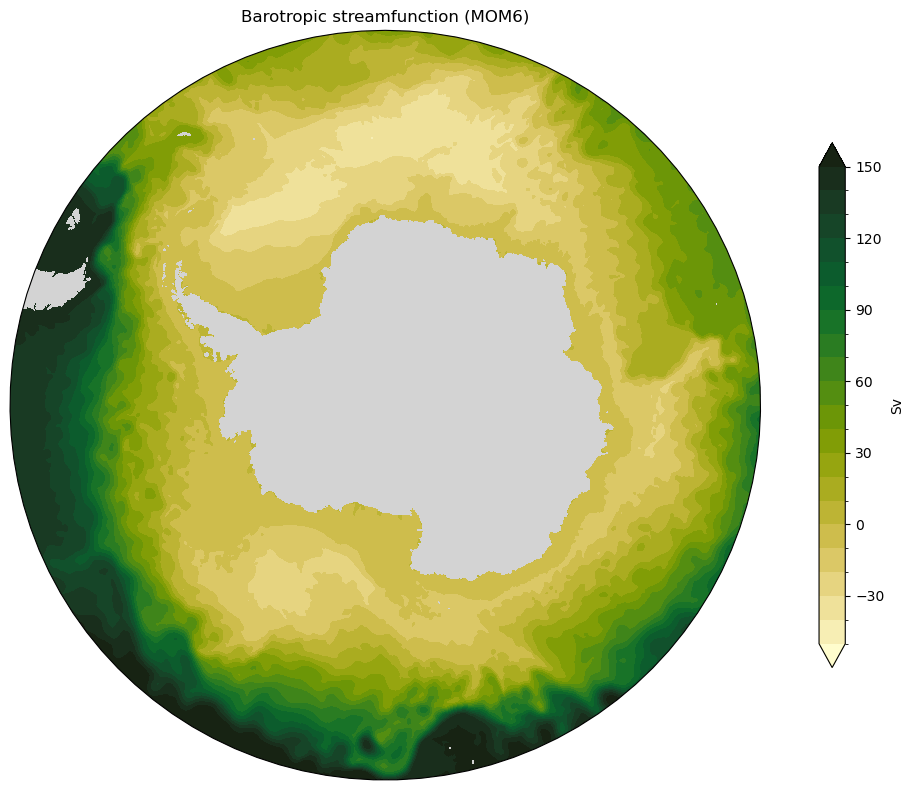

In [21]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -80, -50], crs=ccrs.PlateCarree())
ax.set_facecolor('lightgrey')

# Map the plot boundaries to a circle
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

psi.plot.contourf(ax=ax,
                  levels=np.arange(-50,160,10),
                  extend='both',
                  cmap=cmocean.cm.speed,
                  cbar_kwargs={'shrink':.7, 'label':'Sv'},
                  transform=ccrs.PlateCarree())

land_mask.plot.contourf(ax=ax,
                        colors=['lightgrey'], 
                        add_colorbar=False,
                        transform=ccrs.PlateCarree())


plt.title("Barotropic streamfunction (MOM6)")
plt.tight_layout()